In [2]:
import os
import kagglehub
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

In [3]:
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


In [4]:
import os

print(os.listdir(path))

['test', 'train']


In [5]:
train_dir = os.path.join(path, "train")
test_dir = os.path.join(path, "test")


print(os.listdir(train_dir))
print(os.listdir(test_dir))

['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']
['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']


In [6]:
total = 0
for emotion in os.listdir(train_dir):
    emotion_path = os.path.join(train_dir, emotion)

    num_images = len(os.listdir(emotion_path))
    total += len(os.listdir(emotion_path))

    print(emotion, ":", num_images)

print("Total training images:", total)

surprise : 3171
fear : 4097
angry : 3995
neutral : 4965
sad : 4830
disgust : 436
happy : 7215
Total training images: 28709


In [7]:
total_v = 0
for emotion in os.listdir(test_dir):
    emotion_path = os.path.join(test_dir, emotion)

    num_images = len(os.listdir(emotion_path))
    total_v += len(os.listdir(emotion_path))

    print(emotion, ":", num_images)

print("Total testing images:", total_v)

surprise : 831
fear : 1024
angry : 958
neutral : 1233
sad : 1247
disgust : 111
happy : 1774
Total testing images: 7178


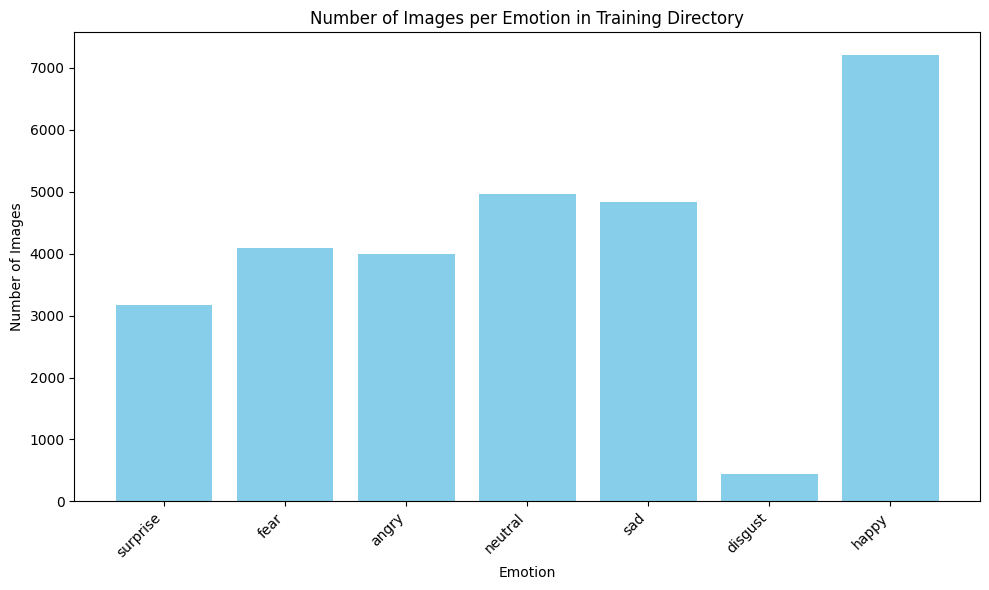

In [7]:
emotion_counts = {}
for emotion in os.listdir(train_dir):
    emotion_path = os.path.join(train_dir, emotion)
    num_images = len(os.listdir(emotion_path))
    emotion_counts[emotion] = num_images

emotions = list(emotion_counts.keys())
counts = list(emotion_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(emotions, counts, color='skyblue')
plt.xlabel('Emotion')
plt.ylabel('Number of Images')
plt.title('Number of Images per Emotion in Training Directory')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

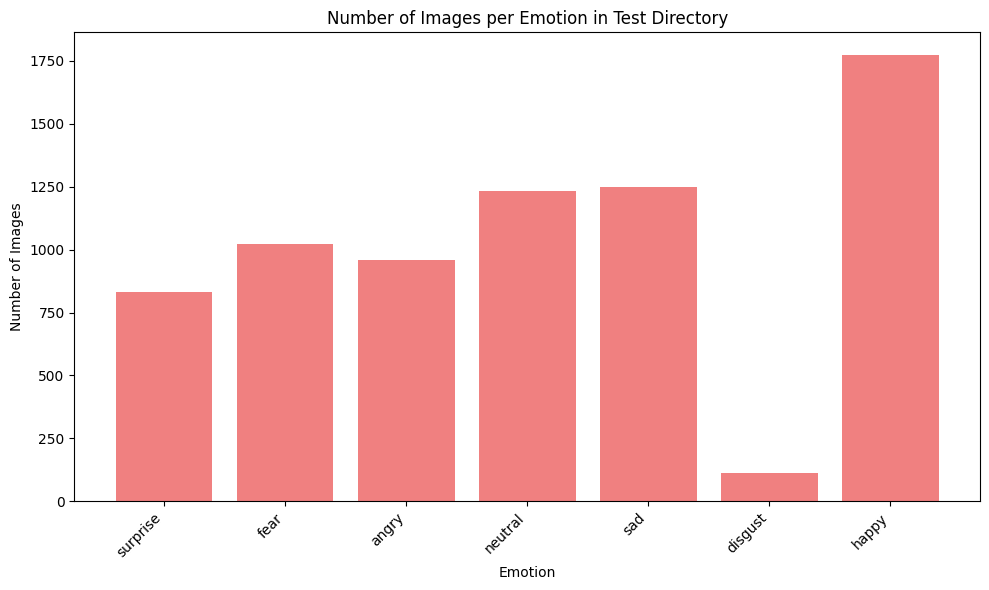

In [8]:
emotion_counts_test = {}
for emotion in os.listdir(test_dir):
    emotion_path = os.path.join(test_dir, emotion)
    num_images = len(os.listdir(emotion_path))
    emotion_counts_test[emotion] = num_images

emotions_test = list(emotion_counts_test.keys())
counts_test = list(emotion_counts_test.values())

plt.figure(figsize=(10, 6))
plt.bar(emotions_test, counts_test, color='lightcoral')
plt.xlabel('Emotion')
plt.ylabel('Number of Images')
plt.title('Number of Images per Emotion in Test Directory')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
"""
removed = 0
for folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, folder)
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        try:
            img = tf.io.read_file(img_path)
            img = tf.image.decode_image(img)
        except:
            print("Removing corrupted file:", img_path)
            os.remove(img_path)
            removed += 1

print("Total removed files:", removed)
"""

'\nremoved = 0\nfor folder in os.listdir(train_dir):\n    folder_path = os.path.join(train_dir, folder)\n    for img_name in os.listdir(folder_path):\n        img_path = os.path.join(folder_path, img_name)\n        try:\n            img = tf.io.read_file(img_path)\n            img = tf.image.decode_image(img)\n        except:\n            print("Removing corrupted file:", img_path)\n            os.remove(img_path)\n            removed += 1\n\nprint("Total removed files:", removed)\n'

In [8]:
batch_size = 64
img_height = 48
img_width = 48

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    color_mode='grayscale',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    seed=123
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    color_mode='grayscale',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
print("Emotion Classes Found:", class_names)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Emotion Classes Found: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


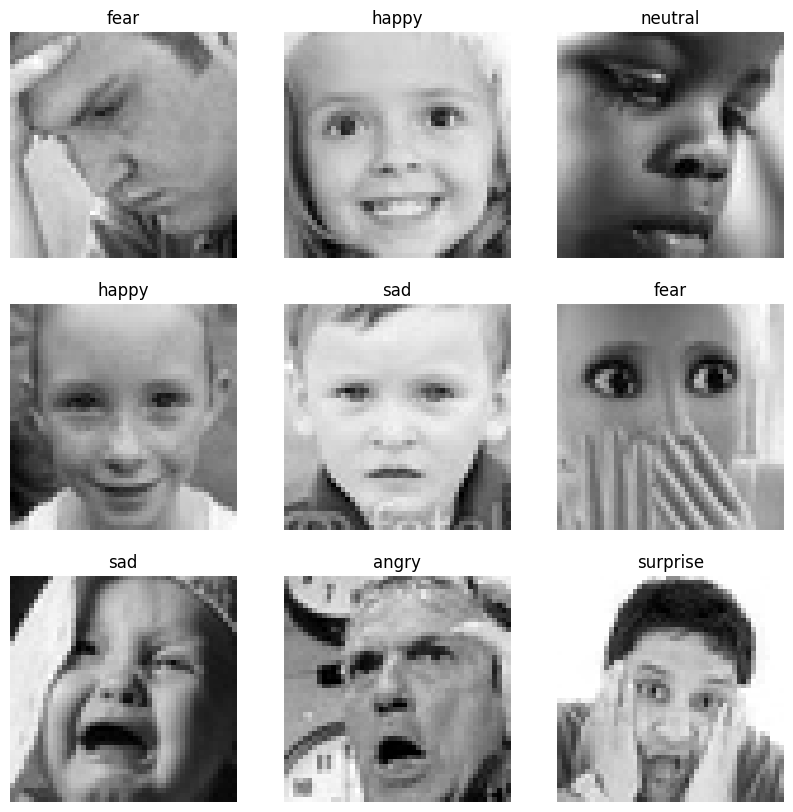

In [17]:
plt.figure(figsize=(10, 10))


for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)


        plt.imshow(images[i].numpy().squeeze(), cmap='gray')


        class_label = class_names[labels[i]]

        plt.title(class_label)
        plt.axis("off")
    break
plt.show()

In [9]:
AUTOTUNE = tf.data.AUTOTUNE
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)

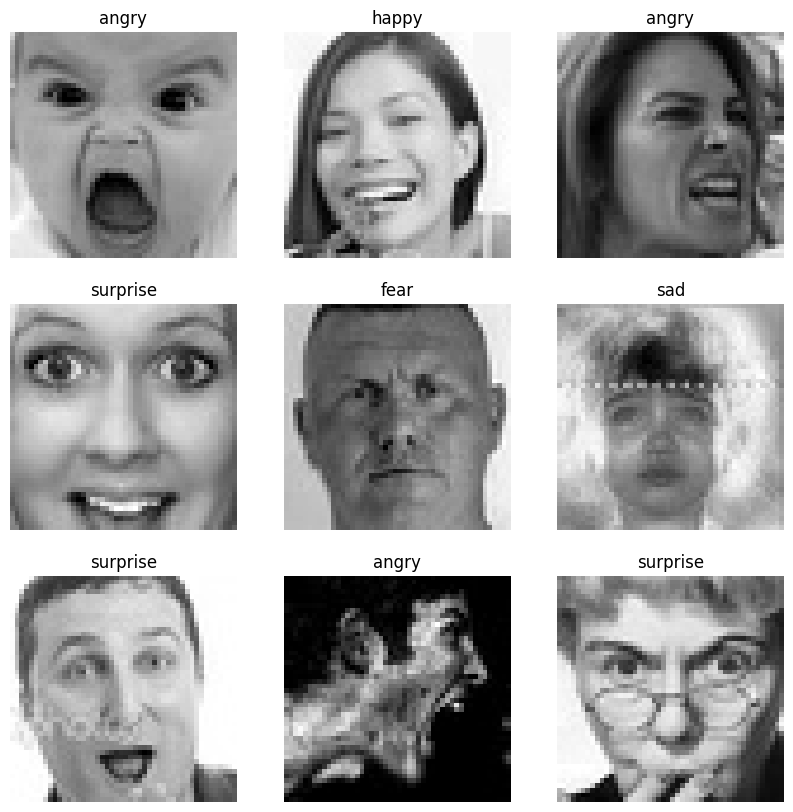

In [19]:
plt.figure(figsize=(10, 10))


for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)


        plt.imshow(images[i].numpy().squeeze(), cmap='gray')


        class_label = class_names[labels[i]]

        plt.title(class_label)
        plt.axis("off")
    break
plt.show()

In [20]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(64, 48, 48, 1)
(64,)


In [21]:
from tensorflow.keras import layers, models

model1 = models.Sequential([
    layers.Input(shape=(img_height, img_width, 1)),


    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),


    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')
])


In [22]:
model1.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

In [23]:
epochs = 20
history_m1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 193s 423ms/step - accuracy: 0.3265 - loss: 1.8745 - val_accuracy: 0.1793 - val_loss: 10.8293
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 172s 383ms/step - accuracy: 0.4416 - loss: 1.4776 - val_accuracy: 0.4635 - val_loss: 1.4385
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 201s 381ms/step - accuracy: 0.4761 - loss: 1.3784 - val_accuracy: 0.4790 - val_loss: 1.3767
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 199s 374ms/step - accuracy: 0.4923 - loss: 1.3369 - val_accuracy: 0.4813 - val_loss: 1.3774
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 176s 391ms/step - accuracy: 0.5105 - loss: 1.2950 - val_accuracy: 0.4646 - val_loss: 1.4316
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 171s 381ms/step - accuracy: 0.5293 - loss: 1.2407 - val_accuracy: 0.5053 - val_loss: 1.3526
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 175s 389ms/step - accuracy: 0.5472 - loss: 1.2007 - val_accuracy: 0.5308 - val_loss: 1.2286
Epoch 8/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 171s 381ms/step - accuracy: 0.5580 

In [24]:
model1.save('model1_CNN_Max.h5')

In [ ]:
# Please specify which model you'd like to save (e.g., model2.save('model2.h5'))

In [25]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,600,279 (13.73 MB)

 Trainable params: 1,199,943 (4.58 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2,399,888 (9.15 MB)

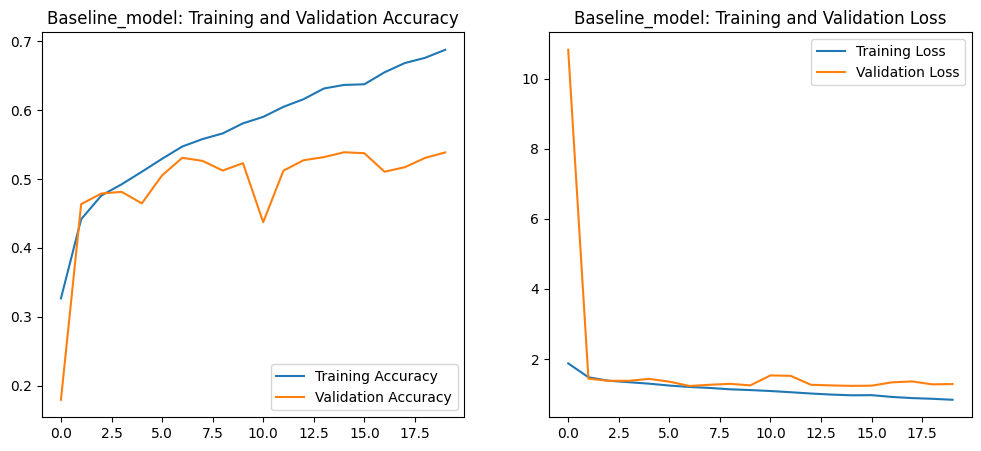

In [26]:
acc = history_m1.history['accuracy']
val_acc = history_m1.history['val_accuracy']

loss = history_m1.history['loss']
val_loss = history_m1.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Baseline_model: Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Baseline_model: Training and Validation Loss')
plt.show()

In [27]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])




In [28]:
model2 = models.Sequential([
        layers.Input(shape=(img_height, img_width, 1)),


        data_augmentation,


        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(7, activation='softmax')
    ])

model2.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])





In [29]:
history_m2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 175s 382ms/step - accuracy: 0.2574 - loss: 2.0372 - val_accuracy: 0.1854 - val_loss: 9.2251
Epoch 2/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 176s 391ms/step - accuracy: 0.3510 - loss: 1.6618 - val_accuracy: 0.3221 - val_loss: 1.7234
Epoch 3/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 204s 395ms/step - accuracy: 0.3845 - loss: 1.5785 - val_accuracy: 0.3408 - val_loss: 1.6703
Epoch 4/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 198s 386ms/step - accuracy: 0.4078 - loss: 1.5290 - val_accuracy: 0.4277 - val_loss: 1.4796
Epoch 5/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 174s 388ms/step - accuracy: 0.4214 - loss: 1.4981 - val_accuracy: 0.4289 - val_loss: 1.4677
Epoch 6/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 173s 386ms/step - accuracy: 0.4283 - loss: 1.4780 - val_accuracy: 0.4368 - val_loss: 1.5610
Epoch 7/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 174s 387ms/step - accuracy: 0.4376 - loss: 1.4582 - val_accuracy: 0.4590 - val_loss: 1.4325
Epoch 8/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 173s 385ms/step - accuracy: 0.4457 -

In [30]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,600,279 (13.73 MB)

 Trainable params: 1,199,943 (4.58 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2,399,888 (9.15 MB)

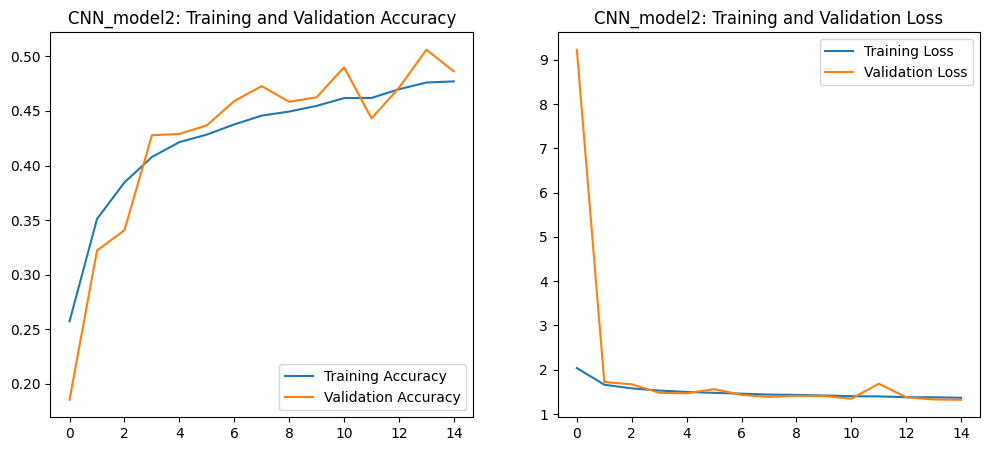

In [32]:
acc = history_m2.history['accuracy']
val_acc = history_m2.history['val_accuracy']

loss = history_m2.history['loss']
val_loss = history_m2.history['val_loss']

epochs_range = range(15)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('CNN_model2: Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('CNN_model2: Training and Validation Loss')
plt.show()

In [33]:
model2.save('model2_CNN_DataAug.h5')

In [34]:
from tensorflow.keras.callbacks import EarlyStopping


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


history_continued = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=[early_stop]
)

Epoch 1/35
449/449 ━━━━━━━━━━━━━━━━━━━━ 190s 423ms/step - accuracy: 0.4759 - loss: 1.3681 - val_accuracy: 0.4968 - val_loss: 1.2989
Epoch 2/35
449/449 ━━━━━━━━━━━━━━━━━━━━ 182s 406ms/step - accuracy: 0.4796 - loss: 1.3596 - val_accuracy: 0.4986 - val_loss: 1.3527
Epoch 3/35
449/449 ━━━━━━━━━━━━━━━━━━━━ 200s 401ms/step - accuracy: 0.4782 - loss: 1.3553 - val_accuracy: 0.4976 - val_loss: 1.3371
Epoch 4/35
449/449 ━━━━━━━━━━━━━━━━━━━━ 180s 400ms/step - accuracy: 0.4823 - loss: 1.3491 - val_accuracy: 0.5089 - val_loss: 1.2669
Epoch 5/35
449/449 ━━━━━━━━━━━━━━━━━━━━ 206s 408ms/step - accuracy: 0.4892 - loss: 1.3412 - val_accuracy: 0.5036 - val_loss: 1.2739
Epoch 6/35
449/449 ━━━━━━━━━━━━━━━━━━━━ 182s 406ms/step - accuracy: 0.4945 - loss: 1.3280 - val_accuracy: 0.5123 - val_loss: 1.2602
Epoch 7/35
449/449 ━━━━━━━━━━━━━━━━━━━━ 179s 398ms/step - accuracy: 0.4869 - loss: 1.3334 - val_accuracy: 0.5178 - val_loss: 1.2790
Epoch 8/35
449/449 ━━━━━━━━━━━━━━━━━━━━ 201s 395ms/step - accuracy: 0.4940 -

In [35]:
model2.save('model2_CNN_DataAug_2.h5')

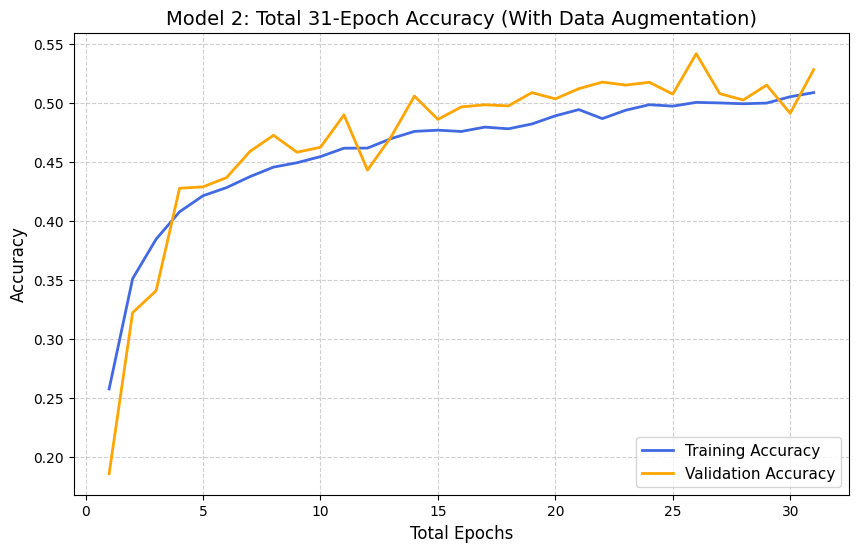

In [41]:
import matplotlib.pyplot as plt


total_accuracy = history_m2.history['accuracy'] + history_continued.history['accuracy']

total_val_accuracy = history_m2.history['val_accuracy'] + history_continued.history['val_accuracy']


epochs_range = range(1, len(total_accuracy) + 1)


plt.figure(figsize=(10, 6))
plt.plot(epochs_range, total_accuracy, label='Training Accuracy', color='royalblue', linewidth=2)
plt.plot(epochs_range, total_val_accuracy, label='Validation Accuracy', color='orange', linewidth=2)


plt.title('Model 2: Total 31-Epoch Accuracy (With Data Augmentation)', fontsize=14)
plt.xlabel('Total Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

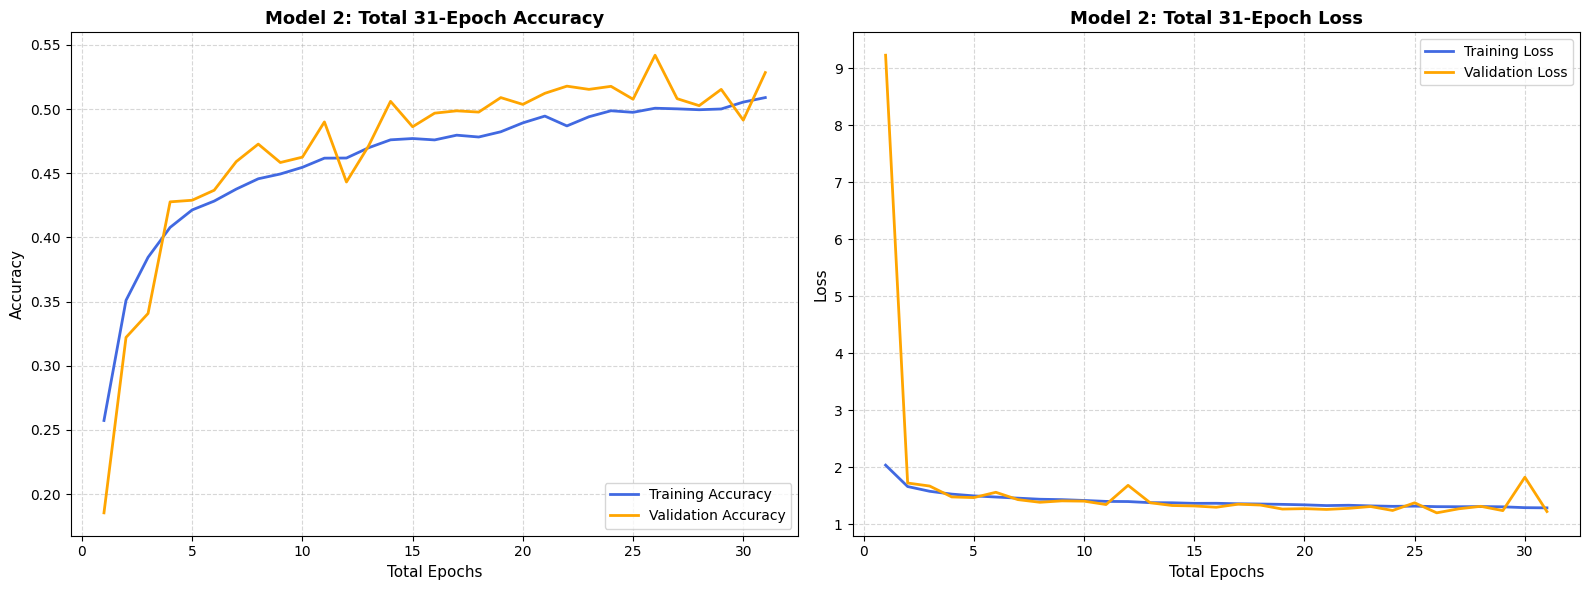

In [42]:
import matplotlib.pyplot as plt

# 1. Combine Training and Validation Accuracy
total_accuracy = history_m2.history['accuracy'] + history_continued.history['accuracy']
total_val_accuracy = history_m2.history['val_accuracy'] + history_continued.history['val_accuracy']

# 2. Combine Training and Validation Loss (New)
total_loss = history_m2.history['loss'] + history_continued.history['loss']
total_val_loss = history_m2.history['val_loss'] + history_continued.history['val_loss']

# Create the continuous 1-31 epoch range
epochs_range = range(1, len(total_accuracy) + 1)

# Set up a wide figure to hold two plots side-by-side
plt.figure(figsize=(16, 6))

# --- SUBPLOT 1: ACCURACY ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, total_accuracy, label='Training Accuracy', color='royalblue', linewidth=2)
plt.plot(epochs_range, total_val_accuracy, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model 2: Total 31-Epoch Accuracy', fontsize=13, fontweight='bold')
plt.xlabel('Total Epochs', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# --- SUBPLOT 2: LOSS ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, total_loss, label='Training Loss', color='royalblue', linewidth=2)
plt.plot(epochs_range, total_val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Model 2: Total 31-Epoch Loss', fontsize=13, fontweight='bold')
plt.xlabel('Total Epochs', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()

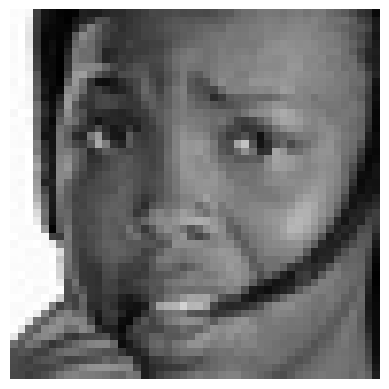

In [72]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image



available_emotions = os.listdir(test_dir)
random_emotion = random.choice(available_emotions)
emotion_folder_path = os.path.join(test_dir, random_emotion)


all_images_in_folder = os.listdir(emotion_folder_path)
random_image_name = random.choice(all_images_in_folder)


img_path = os.path.join(emotion_folder_path, random_image_name)



img = image.load_img(img_path, target_size=(48, 48), color_mode="grayscale")
img = np.array(img)

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()



In [73]:

img_processed = np.expand_dims(img, axis=0)
img_processed = img_processed.reshape(1, 48, 48, 1)

img_processed = img_processed / 255.0




In [62]:
labels = {0:'Angry',1:'Disgust',2:'Fear',3:'Happy',4:'Neutral',5:'Sad',6:'Surprise'}

In [74]:
result_m1 = model1.predict(img_processed)
result_list_m1 = list(result_m1[0])
img_index_m1 = result_list_m1.index(max(result_list_m1))
prediction_m1 = labels[img_index_m1]



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [75]:

result_m2 = model2.predict(img_processed)
result_list_m2 = list(result_m2[0])
img_index_m2 = result_list_m2.index(max(result_list_m2))
prediction_m2 = labels[img_index_m2]



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


In [76]:

print(f"TRUE EMOTION (Ground Truth Folder): {random_emotion.upper()}")

print(f"Model 1 (Baseline) Predicted      : {prediction_m1}")
print(f"Model 2 (Data Augmented) Predicted : {prediction_m2}")


TRUE EMOTION (Ground Truth Folder): FEAR
Model 1 (Baseline) Predicted      : Happy
Model 2 (Data Augmented) Predicted : Fear


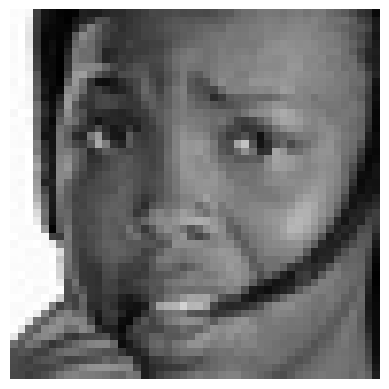

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Model 1 (Baseline) Predicted      : Fear
Model 2 (Data Augmented) Predicted : Fear


In [77]:
img = image.load_img(img_path, target_size=(48, 48), color_mode="grayscale")
img = np.array(img)


plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()


img_processed = np.expand_dims(img, axis=0)
img_processed = img_processed.reshape(1, 48, 48, 1)


result_m1 = model1.predict(img_processed)
result_list_m1 = list(result_m1[0])
img_index_m1 = result_list_m1.index(max(result_list_m1))
prediction_m1 = labels[img_index_m1]


result_m2 = model2.predict(img_processed)
result_list_m2 = list(result_m2[0])
img_index_m2 = result_list_m2.index(max(result_list_m2))
prediction_m2 = labels[img_index_m2]



print(f"Model 1 (Baseline) Predicted      : {prediction_m1}")
print(f"Model 2 (Data Augmented) Predicted : {prediction_m2}")


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam


model3 = models.Sequential()


model3.add(layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(48, 48, 1)))
model3.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model3.add(layers.BatchNormalization())
model3.add(layers.MaxPooling2D(pool_size=(2, 2)))
model3.add(layers.Dropout(0.25))


model3.add(layers.Conv2D(128, (5, 5), padding='same', activation='relu'))
model3.add(layers.BatchNormalization())
model3.add(layers.MaxPooling2D(pool_size=(2, 2)))
model3.add(layers.Dropout(0.25))


model3.add(layers.Conv2D(512, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model3.add(layers.BatchNormalization())
model3.add(layers.MaxPooling2D(pool_size=(2, 2)))
model3.add(layers.Dropout(0.25))


model3.add(layers.Conv2D(512, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model3.add(layers.BatchNormalization())
model3.add(layers.MaxPooling2D(pool_size=(2, 2)))
model3.add(layers.Dropout(0.25))


model3.add(layers.Flatten())
model3.add(layers.Dense(256, activation='relu'))
model3.add(layers.BatchNormalization())
model3.add(layers.Dropout(0.25))

model3.add(layers.Dense(512, activation='relu'))
model3.add(layers.BatchNormalization())
model3.add(layers.Dropout(0.25))


model3.add(layers.Dense(7, activation='softmax'))

model3.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,496,903 (17.15 MB)

 Trainable params: 4,492,935 (17.14 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [11]:
history_m3 = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
)

Epoch 1/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 98s 180ms/step - accuracy: 0.2100 - loss: 9.1169 - val_accuracy: 0.1874 - val_loss: 8.6371
Epoch 2/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.2818 - loss: 7.8269 - val_accuracy: 0.3497 - val_loss: 7.0413
Epoch 3/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.3246 - loss: 6.6407 - val_accuracy: 0.3728 - val_loss: 5.9564
Epoch 4/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.3650 - loss: 5.5895 - val_accuracy: 0.4032 - val_loss: 5.0501
Epoch 5/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.3934 - loss: 4.6808 - val_accuracy: 0.4381 - val_loss: 4.1961
Epoch 6/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.4273 - loss: 3.9388 - val_accuracy: 0.4678 - val_loss: 3.5646
Epoch 7/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.4607 - loss: 3.3488 - val_accuracy: 0.4855 - val_loss: 3.1035
Epoch 8/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.4841 - loss: 2.8957 -

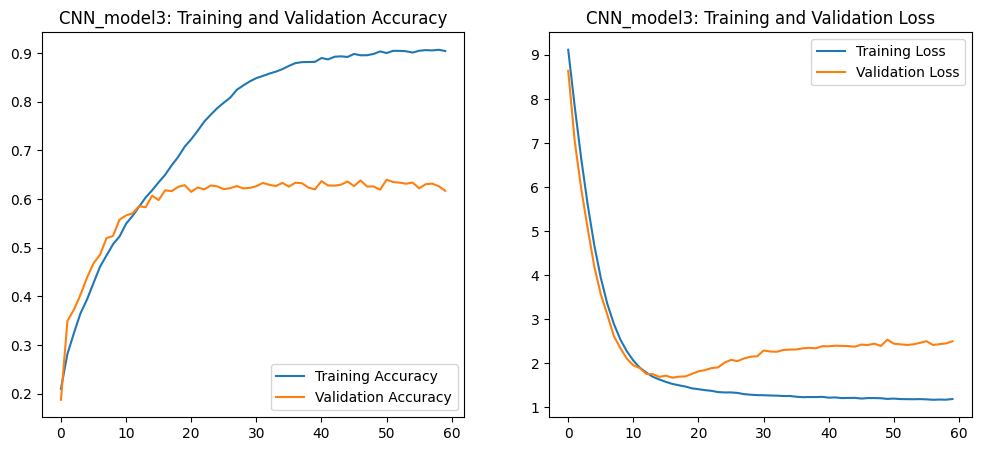

In [21]:
acc = history_m3.history['accuracy']
val_acc = history_m3.history['val_accuracy']

loss = history_m3.history['loss']
val_loss = history_m3.history['val_loss']

epochs_range = range(60)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('CNN_model3: Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('CNN_model3: Training and Validation Loss')
plt.show()

In [15]:
model3.save('model3.h5')

In [16]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam


model4 = models.Sequential()


model4.add(data_augmentation)


model4.add(layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(48, 48, 1)))
model4.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model4.add(layers.BatchNormalization())
model4.add(layers.MaxPooling2D(pool_size=(2, 2)))
model4.add(layers.Dropout(0.25))


model4.add(layers.Conv2D(128, (5, 5), padding='same', activation='relu'))
model4.add(layers.BatchNormalization())
model4.add(layers.MaxPooling2D(pool_size=(2, 2)))
model4.add(layers.Dropout(0.25))


model4.add(layers.Conv2D(512, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model4.add(layers.BatchNormalization())
model4.add(layers.MaxPooling2D(pool_size=(2, 2)))
model4.add(layers.Dropout(0.25))


model4.add(layers.Conv2D(512, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model4.add(layers.BatchNormalization())
model4.add(layers.MaxPooling2D(pool_size=(2, 2)))
model4.add(layers.Dropout(0.25))


model4.add(layers.Flatten())
model4.add(layers.Dense(256, activation='relu'))
model4.add(layers.BatchNormalization())
model4.add(layers.Dropout(0.25))

model4.add(layers.Dense(512, activation='relu'))
model4.add(layers.BatchNormalization())
model4.add(layers.Dropout(0.25))


model4.add(layers.Dense(7, activation='softmax'))


model4.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model4.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:

history_m3_final = model4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,

)

Epoch 1/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 38s 59ms/step - accuracy: 0.1895 - loss: 9.1456 - val_accuracy: 0.1730 - val_loss: 8.6051
Epoch 2/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.2237 - loss: 7.8194 - val_accuracy: 0.2956 - val_loss: 6.9145
Epoch 3/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.2481 - loss: 6.5548 - val_accuracy: 0.3192 - val_loss: 5.7202
Epoch 4/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.2774 - loss: 5.3902 - val_accuracy: 0.3314 - val_loss: 4.6969
Epoch 5/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.3044 - loss: 4.4252 - val_accuracy: 0.3579 - val_loss: 3.8588
Epoch 6/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.3361 - loss: 3.6589 - val_accuracy: 0.3682 - val_loss: 3.2861
Epoch 7/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.3647 - loss: 3.1008 - val_accuracy: 0.4400 - val_loss: 2.6938
Epoch 8/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.3893 - loss: 2.7108 - 

In [20]:
model4.save('model4.h5')

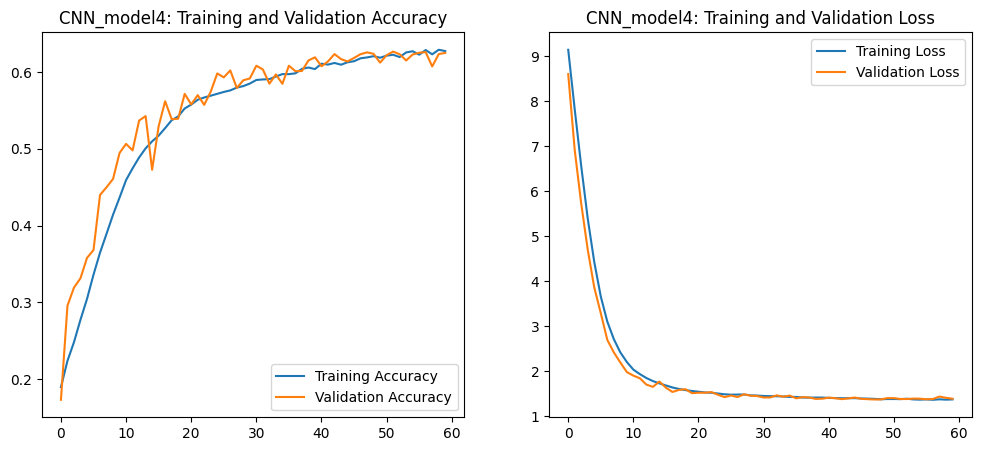

In [22]:
acc = history_m3_final.history['accuracy']
val_acc = history_m3_final.history['val_accuracy']

loss = history_m3_final.history['loss']
val_loss = history_m3_final.history['val_loss']

epochs_range = range(60)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('CNN_model4: Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('CNN_model4: Training and Validation Loss')
plt.show()